
# Week 3: Machine Learning and Computer Vision Fundamentals for Disaster Management

## Overview
This notebook introduces the core machine learning and computer vision concepts used throughout the rest of the course. The focus is on understanding how disaster problems can be framed as classification, object detection, and semantic segmentation tasks.

## Learning Objectives
- Distinguish between classification, detection, and segmentation
- Understand common evaluation metrics such as accuracy, precision, recall, F1 score, and Intersection over Union (IoU)
- Build intuition for how computer vision supports disaster management workflows
- Interpret model outputs in a practical disaster context

## Expected Outcome
By the end of this notebook, you should understand the major computer vision task types and be able to compute and interpret common performance metrics.



## Notebook Structure

1. Environment setup  
2. Why machine learning matters in disaster management  
3. Three core vision tasks  
4. Classification example  
5. Object detection example  
6. Segmentation example  
7. Evaluation metrics  
8. Mini exercise  
9. Weekly assignment  

> This notebook uses simple synthetic examples to build intuition before working with larger GeoAI workflows.


In [1]:

# Week 3 setup: imports and environment check

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

print("Python version:", sys.version.split()[0])
print("Working directory:", os.getcwd())


Python version: 3.12.13
Working directory: /content


In [2]:

# Create output folder for this week

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "week03"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory ready:", OUTPUT_DIR)


Output directory ready: /content/outputs/week03



## Why Machine Learning Matters in Disaster Management

Disaster management problems often involve large volumes of imagery, sensor data, and time-sensitive decisions. Machine learning helps by finding patterns quickly and consistently.

Typical uses include:
- **Classification:** Is this image flooded or not flooded?
- **Object detection:** Where are the vehicles, people, or damaged buildings?
- **Segmentation:** Which exact pixels belong to water, debris, or damaged areas?

The same disaster scene may require all three tasks in sequence.



## Three Core Computer Vision Tasks

### 1. Classification
Classification assigns one label to the entire image or input.
- Example: flood vs. non-flood

### 2. Object Detection
Object detection identifies both **what** is present and **where** it is located.
- Example: detect vehicles in a flooded street scene

### 3. Semantic Segmentation
Segmentation assigns a label to each pixel.
- Example: map the full spatial extent of floodwater

A useful rule:
- **Classification** answers *what is in this image?*
- **Detection** answers *what is in this image and where?*
- **Segmentation** answers *which exact pixels belong to the target class?*


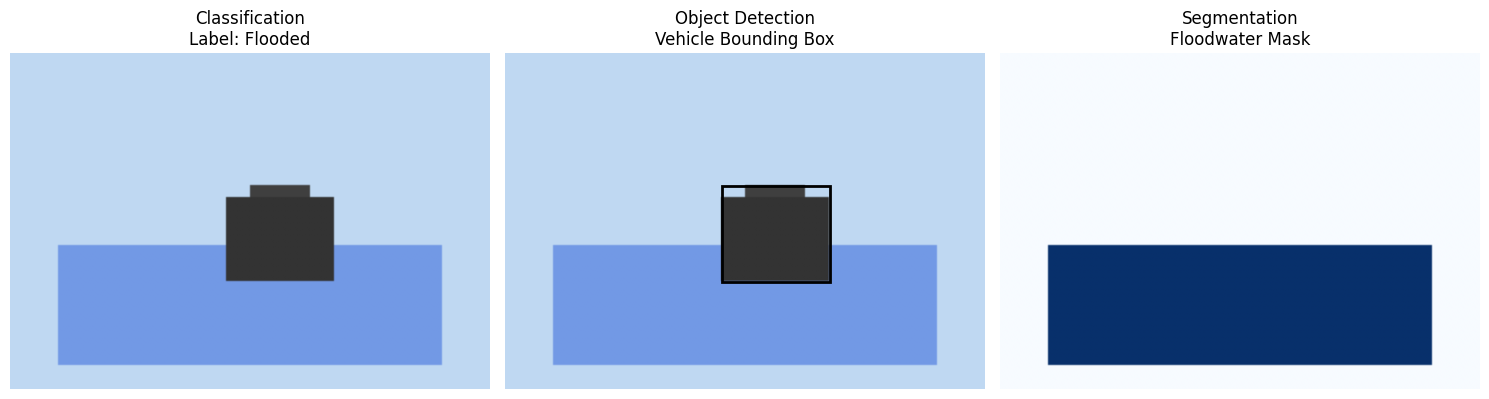

In [3]:

# Visual illustration of the three task types using synthetic examples

img = np.ones((140, 200, 3))
img[..., 0] *= 0.75
img[..., 1] *= 0.85
img[..., 2] *= 0.95

# Add synthetic floodwater
img[80:130, 20:180, 2] = 0.9
img[80:130, 20:180, 1] = 0.6
img[80:130, 20:180, 0] = 0.45

# Add synthetic vehicle
img[60:95, 90:135, :] = 0.2
img[55:60, 100:125, :] = 0.25

mask = np.zeros((140, 200))
mask[80:130, 20:180] = 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Classification
axes[0].imshow(img)
axes[0].set_title("Classification\nLabel: Flooded")
axes[0].axis("off")

# Detection
axes[1].imshow(img)
axes[1].add_patch(Rectangle((90, 55), 45, 40, fill=False, linewidth=2))
axes[1].set_title("Object Detection\nVehicle Bounding Box")
axes[1].axis("off")

# Segmentation
axes[2].imshow(mask, cmap="Blues")
axes[2].set_title("Segmentation\nFloodwater Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()



## Classification Example

Suppose we want to classify images as either:
- **Flooded**
- **Not Flooded**

A classifier does not tell us where the flood is. It only gives a label for the full image.


In [4]:

# Synthetic binary classification example

y_true = np.array([1, 1, 1, 1, 0, 0, 0, 0, 1, 0])   # 1 = flooded, 0 = not flooded
y_pred = np.array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0])

classification_df = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred
})

classification_df


,Actual,Predicted
0,1,1
1,1,1
2,1,0
3,1,1
4,0,0
5,0,0
6,0,1
7,0,0
8,1,1
9,0,0


In [5]:

# Basic metric functions for binary classification

def confusion_counts(y_true, y_pred):
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return tp, tn, fp, fn

def accuracy_score_manual(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def precision_score_manual(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score_manual(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score_manual(y_true, y_pred):
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

tp, tn, fp, fn = confusion_counts(y_true, y_pred)

metrics_df = pd.DataFrame({
    "Metric": ["TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [
        tp, tn, fp, fn,
        round(accuracy_score_manual(y_true, y_pred), 3),
        round(precision_score_manual(y_true, y_pred), 3),
        round(recall_score_manual(y_true, y_pred), 3),
        round(f1_score_manual(y_true, y_pred), 3)
    ]
})

metrics_df


,Metric,Value
0,TP,4.0
1,TN,4.0
2,FP,1.0
3,FN,1.0
4,Accuracy,0.8
5,Precision,0.8
6,Recall,0.8
7,F1 Score,0.8



### Interpreting the Metrics
- **Accuracy** tells us overall correctness.
- **Precision** tells us how often a predicted flood image was actually flooded.
- **Recall** tells us how many true flood images were successfully found.
- **F1 Score** balances precision and recall.

In disaster applications, **recall is often especially important** when missing a true hazard is costly.


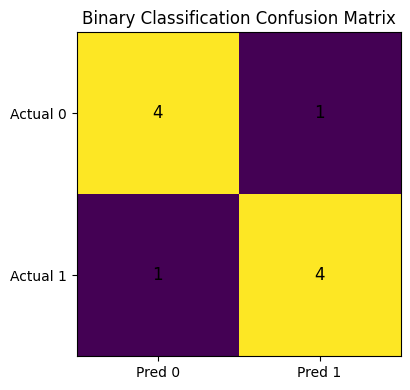

In [6]:

# Visualize confusion matrix counts

conf_matrix = np.array([[tn, fp],
                        [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(conf_matrix)
ax.set_title("Binary Classification Confusion Matrix")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, conf_matrix[i, j], ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.show()



## Object Detection Example

Object detection predicts bounding boxes around targets. A key idea here is **localization quality**.

A model might detect the right object class but place the box poorly. That is why **Intersection over Union (IoU)** matters.


In [7]:

# IoU for object detection

def box_iou(box_a, box_b):
    xA = max(box_a[0], box_b[0])
    yA = max(box_a[1], box_b[1])
    xB = min(box_a[2], box_b[2])
    yB = min(box_a[3], box_b[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    area_a = max(0, box_a[2] - box_a[0]) * max(0, box_a[3] - box_a[1])
    area_b = max(0, box_b[2] - box_b[0]) * max(0, box_b[3] - box_b[1])

    union_area = area_a + area_b - inter_area
    return inter_area / union_area if union_area > 0 else 0.0

ground_truth_box = [60, 45, 125, 100]
predicted_box = [70, 50, 135, 105]

iou_value = box_iou(ground_truth_box, predicted_box)
print("IoU:", round(iou_value, 3))


IoU: 0.625


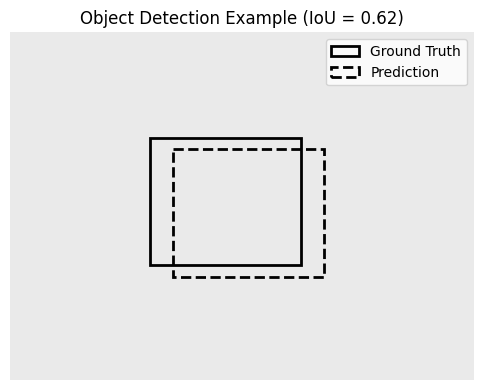

In [8]:

# Plot ground-truth and predicted bounding boxes

canvas = np.ones((150, 200, 3)) * 0.92

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(canvas)
ax.add_patch(Rectangle((ground_truth_box[0], ground_truth_box[1]),
                       ground_truth_box[2] - ground_truth_box[0],
                       ground_truth_box[3] - ground_truth_box[1],
                       fill=False, linewidth=2, label="Ground Truth"))

ax.add_patch(Rectangle((predicted_box[0], predicted_box[1]),
                       predicted_box[2] - predicted_box[0],
                       predicted_box[3] - predicted_box[1],
                       fill=False, linewidth=2, linestyle="--", label="Prediction"))

ax.set_title(f"Object Detection Example (IoU = {iou_value:.2f})")
ax.axis("off")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()



### Interpreting IoU
- **High IoU** means the predicted box overlaps well with the ground truth.
- **Low IoU** means the object was poorly localized.

In practice, a threshold such as **0.5** is often used to decide whether a predicted detection counts as correct.



## Segmentation Example

Segmentation predicts a mask, not a box. This is especially useful in flood mapping because water can cover irregular shapes across a scene.


In [9]:

# Synthetic segmentation masks and IoU / Dice score

true_mask = np.zeros((80, 120), dtype=int)
true_mask[25:65, 20:95] = 1

pred_mask = np.zeros((80, 120), dtype=int)
pred_mask[30:68, 28:100] = 1

def mask_iou(y_true_mask, y_pred_mask):
    intersection = np.logical_and(y_true_mask == 1, y_pred_mask == 1).sum()
    union = np.logical_or(y_true_mask == 1, y_pred_mask == 1).sum()
    return intersection / union if union > 0 else 0.0

def dice_score(y_true_mask, y_pred_mask):
    intersection = np.logical_and(y_true_mask == 1, y_pred_mask == 1).sum()
    total = (y_true_mask == 1).sum() + (y_pred_mask == 1).sum()
    return 2 * intersection / total if total > 0 else 0.0

seg_iou = mask_iou(true_mask, pred_mask)
seg_dice = dice_score(true_mask, pred_mask)

print("Segmentation IoU:", round(seg_iou, 3))
print("Dice Score:", round(seg_dice, 3))


Segmentation IoU: 0.692
Dice Score: 0.818


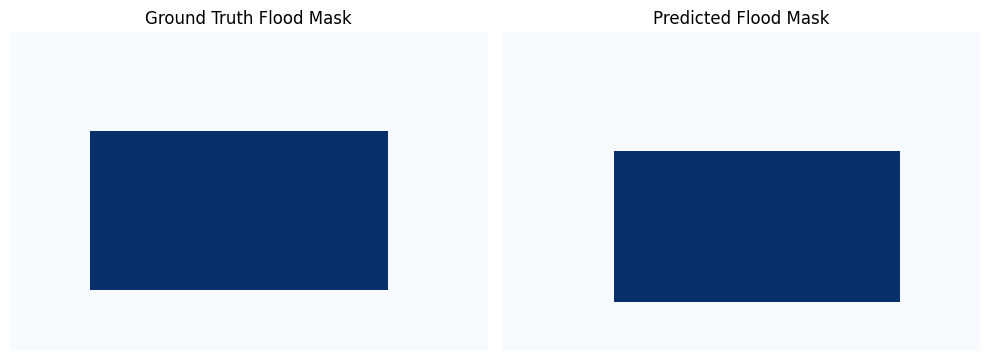

In [10]:

# Visualize true and predicted masks

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(true_mask, cmap="Blues")
axes[0].set_title("Ground Truth Flood Mask")
axes[0].axis("off")

axes[1].imshow(pred_mask, cmap="Blues")
axes[1].set_title("Predicted Flood Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()



### Why Segmentation Matters
For flood analysis, segmentation can provide:
- flood extent
- inundation boundaries
- water coverage ratios
- better spatial interpretation than simple image labels

This is why segmentation is a major method in remote sensing flood mapping.



## Metric Summary Table


In [11]:

metric_summary = pd.DataFrame([
    {
        "Task Type": "Classification",
        "Main Output": "Single label",
        "Typical Metrics": "Accuracy, Precision, Recall, F1",
        "Example Disaster Use": "Flooded vs. non-flooded image"
    },
    {
        "Task Type": "Object Detection",
        "Main Output": "Bounding boxes + labels",
        "Typical Metrics": "IoU, Precision, Recall, mAP",
        "Example Disaster Use": "Detect vehicles or damaged buildings"
    },
    {
        "Task Type": "Segmentation",
        "Main Output": "Pixel-wise mask",
        "Typical Metrics": "IoU, Dice, Pixel Accuracy",
        "Example Disaster Use": "Flood extent mapping"
    }
])

metric_summary


,Task Type,Main Output,Typical Metrics,Example Disaster Use
0,Classification,Single label,"Accuracy, Precision, Recall, F1",Flooded vs. non-flooded image
1,Object Detection,Bounding boxes + labels,"IoU, Precision, Recall, mAP",Detect vehicles or damaged buildings
2,Segmentation,Pixel-wise mask,"IoU, Dice, Pixel Accuracy",Flood extent mapping



## Choosing the Right Task

A useful question to ask is:

> What kind of answer do I need from the model?

- If you only need a scene-level label, use **classification**.
- If you need object locations, use **detection**.
- If you need exact affected area, use **segmentation**.

Many real disaster systems combine all three.



## Mini Exercise

Answer the following in your own words:

1. Why might high recall matter more than high precision in some disaster settings?
2. What does IoU tell us in object detection?
3. Why is segmentation often more informative than classification for flood mapping?

Write your responses below.


In [12]:

# Write your Week 3 mini exercise responses here

# 1.
# 2.
# 3.



## Weekly Assignment

Choose **one disaster application** below:
- flood scene classification
- damaged building detection
- flood extent mapping
- wildfire burn area mapping

### Your task
Write a short response that includes:
1. The most suitable task type: classification, detection, or segmentation
2. Why that task type is the best fit
3. One useful evaluation metric
4. One challenge you would expect in a real-world deployment

You can answer in a markdown cell or the code cell below.


In [13]:

# Write your Week 3 assignment response here

application = ""
task_type = ""
metric = ""
challenge = ""

print("Application:", application)
print("Task Type:", task_type)
print("Metric:", metric)
print("Challenge:", challenge)


Application: 
Task Type: 
Metric: 
Challenge: 



## Key Takeaway

The main lesson from Week 3 is:

> **Different disaster questions require different AI task formulations.**

Classification, detection, and segmentation are not interchangeable. Each solves a different problem, and choosing the correct task type is one of the most important decisions in building a useful disaster AI workflow.



## Suggested Extensions
Later, this notebook can be expanded with:
- a real image classification example
- a pretrained object detector
- a simple segmentation model
- precision-recall curve visualization
- a confusion matrix from a larger dataset

For now, this notebook builds the conceptual foundation needed for the later flood-focused weeks.
